In [1]:
import sys
import torch
import os
from pathlib import Path

print("=== Ambiente ===")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print("\n=== Inputs ===")
for item in sorted(os.listdir('/kaggle/input/')):
    print(f"  /kaggle/input/{item}")

=== Ambiente ===
Python: 3.12.12
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 15.6 GB

=== Inputs ===
  /kaggle/input/competitions


In [2]:
!pip install facenet-pytorch --no-deps -q
!pip install timm -q
print("Dependências instaladas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 6.8 MB/s eta 0:00:0000:0100:01
Dependências instaladas


In [3]:
import sys
import torch

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.12.12
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


In [4]:
import os
import sys
import json
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from facenet_pytorch import MTCNN

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, roc_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

POSSIBLE_PATHS = [
    '/kaggle/input/competitions/deepfake-detection-challenge/train_sample_videos',
]
VIDEOS_PATH = None
for p in POSSIBLE_PATHS:
    if Path(p).exists():
        VIDEOS_PATH = Path(p)
        break
assert VIDEOS_PATH is not None, "DFDC não encontrado!"

WORK_DIR = Path('/kaggle/working')
FACES_DIR = WORK_DIR / 'faces'
FACES_DIR.mkdir(exist_ok=True, parents=True)

FRAMES_PER_VIDEO = 10
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 8
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

print(" Imports feitos")
print(f"   Python: {sys.version.split()[0]}")
print(f"   PyTorch: {torch.__version__}")
print(f"   Device: {device}")
print(f"   VIDEOS_PATH: {VIDEOS_PATH}")
print(f"   SEED: {SEED}")

 Imports feitos
   Python: 3.12.12
   PyTorch: 2.10.0+cu128
   Device: cuda
   VIDEOS_PATH: /kaggle/input/competitions/deepfake-detection-challenge/train_sample_videos
   SEED: 42


In [5]:
POSSIBLE_PATHS = [
    '/kaggle/input/competitions/deepfake-detection-challenge/train_sample_videos',
]
VIDEOS_PATH = None
for p in POSSIBLE_PATHS:
    if Path(p).exists():
        VIDEOS_PATH = Path(p)
        break

assert VIDEOS_PATH is not None, "Nenhum caminho do DFDC encontrado!"
print(f"DFDC em: {VIDEOS_PATH}")

WORK_DIR = Path('/kaggle/working')
FACES_DIR = WORK_DIR / 'faces'
FACES_DIR.mkdir(exist_ok=True, parents=True)

FRAMES_PER_VIDEO = 10       
IMG_SIZE = 224               
BATCH_SIZE = 32
NUM_EPOCHS = 8
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

print(f"   Configurações definidas")
print(f"   Frames/vídeo: {FRAMES_PER_VIDEO}")
print(f"   Tamanho imagem: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Épocas: {NUM_EPOCHS}")

DFDC em: /kaggle/input/competitions/deepfake-detection-challenge/train_sample_videos
   Configurações definidas
   Frames/vídeo: 10
   Tamanho imagem: 224x224
   Batch size: 32
   Épocas: 8


In [6]:
with open(VIDEOS_PATH / 'metadata.json', 'r') as f:
    metadata = json.load(f)

df = pd.DataFrame([
    {'filename': k, 'label': v['label'], 'original': v.get('original')}
    for k, v in metadata.items()
])

print(f"Total vídeos: {len(df)}")
print(f"\nDistribuição:")
print(df['label'].value_counts())
print(f"\nREAL únicos (identities): {df[df['label']=='REAL']['filename'].nunique()}")
print(f"FAKEs com original definido: {df[df['label']=='FAKE']['original'].notna().sum()}")

fakes_per_real = df[df['label']=='FAKE'].groupby('original').size()
print(f"\nFakes por cada REAL:")
print(f"  Média: {fakes_per_real.mean():.1f}")
print(f"  Min: {fakes_per_real.min()}, Max: {fakes_per_real.max()}")

Total vídeos: 400

Distribuição:
label
FAKE    323
REAL     77
Name: count, dtype: int64

REAL únicos (identities): 77
FAKEs com original definido: 323

Fakes por cada REAL:
  Média: 1.5
  Min: 1, Max: 6


In [7]:
import random
import numpy as np
import torch

# Seed para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"SEED: {SEED}")

Device: cuda
SEED: 42


In [8]:
POSSIBLE_PATHS = [
    '/kaggle/input/competitions/deepfake-detection-challenge/train_sample_videos',
]
VIDEOS_PATH = None
for p in POSSIBLE_PATHS:
    if Path(p).exists():
        VIDEOS_PATH = Path(p)
        break
assert VIDEOS_PATH is not None, "Nenhum caminho do DFDC encontrado!"
print(f" DFDC em: {VIDEOS_PATH}")

WORK_DIR = Path('/kaggle/working')
FACES_DIR = WORK_DIR / 'faces'
FACES_DIR.mkdir(exist_ok=True, parents=True)

FRAMES_PER_VIDEO = 10        
IMG_SIZE = 224               
BATCH_SIZE = 32
NUM_EPOCHS = 8
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

print(f"   Configurações definidas")
print(f"   Frames/vídeo: {FRAMES_PER_VIDEO}")
print(f"   Tamanho imagem: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Épocas: {NUM_EPOCHS}")

 DFDC em: /kaggle/input/competitions/deepfake-detection-challenge/train_sample_videos
   Configurações definidas
   Frames/vídeo: 10
   Tamanho imagem: 224x224
   Batch size: 32
   Épocas: 8


In [9]:
with open(VIDEOS_PATH / 'metadata.json', 'r') as f:
    metadata = json.load(f)

# DataFrame para análise
df = pd.DataFrame([
    {'filename': k, 'label': v['label'], 'original': v.get('original')}
    for k, v in metadata.items()
])

print(f"Total vídeos: {len(df)}")
print(f"\nDistribuição:")
print(df['label'].value_counts())
print(f"\nREAL únicos (identities): {df[df['label']=='REAL']['filename'].nunique()}")
print(f"FAKEs com original definido: {df[df['label']=='FAKE']['original'].notna().sum()}")

# Quantos fakes por cada real?
fakes_per_real = df[df['label']=='FAKE'].groupby('original').size()
print(f"\nFakes por cada REAL:")
print(f"  Média: {fakes_per_real.mean():.1f}")
print(f"  Min: {fakes_per_real.min()}, Max: {fakes_per_real.max()}")

Total vídeos: 400

Distribuição:
label
FAKE    323
REAL     77
Name: count, dtype: int64

REAL únicos (identities): 77
FAKEs com original definido: 323

Fakes por cada REAL:
  Média: 1.5
  Min: 1, Max: 6


In [11]:
df['split'] = None

# 1. Split dos Reais 
real_identities = df[df['label']=='REAL']['filename'].tolist()
random.seed(SEED)
random.shuffle(real_identities)

n = len(real_identities)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_ids = set(real_identities[:n_train])
val_ids = set(real_identities[n_train:n_train+n_val])
test_ids = set(real_identities[n_train+n_val:])

# 2. Atribuir split aos REAIS
def split_real(filename):
    if filename in train_ids: return 'train'
    elif filename in val_ids: return 'val'
    elif filename in test_ids: return 'test'
    return 'unknown'

df.loc[df['label']=='REAL', 'split'] = df[df['label']=='REAL']['filename'].apply(split_real)

# 3. FAKEs
real_filenames = set(df[df['label']=='REAL']['filename'].tolist())
real_to_split = {
    **{r: 'train' for r in train_ids},
    **{r: 'val' for r in val_ids},
    **{r: 'test' for r in test_ids},
}

# 3a. FAKEs orphan, os originais não estão neste datasset de teste 
orphan_fakes = df[(df['label']=='FAKE') & 
                   (~df['original'].isin(real_filenames))]['filename'].tolist()
random.seed(SEED + 1)
random.shuffle(orphan_fakes)

n_orph = len(orphan_fakes)
n_orph_train = int(0.7 * n_orph)
n_orph_val = int(0.15 * n_orph)

orphan_split = {}
for i, f in enumerate(orphan_fakes):
    if i < n_orph_train:
        orphan_split[f] = 'train'
    elif i < n_orph_train + n_orph_val:
        orphan_split[f] = 'val'
    else:
        orphan_split[f] = 'test'

# 3b. Atribuir split aos FAKEs
def split_fake(row):
    if row['original'] in real_to_split:
        return real_to_split[row['original']]
    else:
        return orphan_split.get(row['filename'], 'unknown')

df.loc[df['label']=='FAKE', 'split'] = df[df['label']=='FAKE'].apply(split_fake, axis=1)

# === VERIFICAÇÃO ===
print("Distribuição final:")
print(df.groupby(['split', 'label']).size().unstack(fill_value=0))

unknown_count = (df['split'] == 'unknown').sum()
print(f"\nUnknowns restantes: {unknown_count} (deve ser 0)")

print(f"\nResumo por split:")
for s in ['train', 'val', 'test']:
    n_real = ((df['split']==s) & (df['label']=='REAL')).sum()
    n_fake = ((df['split']==s) & (df['label']=='FAKE')).sum()
    n_total = n_real + n_fake
    print(f"  {s:5s}: {n_total:3d} vídeos ({n_real:3d} REAL + {n_fake:3d} FAKE) — ratio FAKE/total: {n_fake/n_total:.2%}")

Distribuição final:
label  FAKE  REAL
split            
test     45    13
train   233    53
val      45    11

Unknowns restantes: 0 (deve ser 0)

Resumo por split:
  train: 286 vídeos ( 53 REAL + 233 FAKE) — ratio FAKE/total: 81.47%
  val  :  56 vídeos ( 11 REAL +  45 FAKE) — ratio FAKE/total: 80.36%
  test :  58 vídeos ( 13 REAL +  45 FAKE) — ratio FAKE/total: 77.59%


In [12]:
# Inicializar MTCNN 
mtcnn = MTCNN(
    image_size=IMG_SIZE,
    margin=40,
    keep_all=False,      
    post_process=False,  
    device=device,
    select_largest=True  
)

def extract_frames_from_video(video_path, num_frames=FRAMES_PER_VIDEO):
    """
    Extrai `num_frames` frames uniformemente espaçados do vídeo.
    Retorna lista de arrays numpy RGB.
    """
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return []
    
    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

def extract_faces_from_video(video_path, output_dir, video_name, label,
                              num_frames=FRAMES_PER_VIDEO):
    """
    Extrai faces de um vídeo e guarda em output_dir.
    Retorna lista de caminhos das faces guardadas.
    """
    frames = extract_frames_from_video(video_path, num_frames)
    if not frames:
        return []
    
    saved_paths = []
    base_name = Path(video_name).stem 
    
    for i, frame in enumerate(frames):
        face = mtcnn(frame)  
        if face is None:
            continue
        
        face_np = face.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
        face_img = Image.fromarray(face_np)
        
        out_path = output_dir / label / f"{base_name}_frame{i:02d}.jpg"
        out_path.parent.mkdir(exist_ok=True, parents=True)
        face_img.save(out_path, quality=95)
        saved_paths.append(out_path)
    
    return saved_paths

print("Funções de extração definidas")

# Teste rápido em 1 vídeo
test_video = VIDEOS_PATH / df.iloc[0]['filename']
test_frames = extract_frames_from_video(test_video, num_frames=3)
print(f"\nTeste: extraídos {len(test_frames)} frames de {test_video.name}")

Funções de extração definidas

Teste: extraídos 3 frames de aagfhgtpmv.mp4


In [13]:
from tqdm.notebook import tqdm

face_records = []

print(f"Extraindo faces de {len(df)} vídeos...")

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Vídeos"):
    video_path = VIDEOS_PATH / row['filename']
    label = row['label']
    split = row['split']
    
    saved = extract_faces_from_video(
        video_path=video_path,
        output_dir=FACES_DIR,
        video_name=row['filename'],
        label=label,
        num_frames=FRAMES_PER_VIDEO
    )
    
    for path in saved:
        face_records.append({
            'path': str(path),
            'label': label,
            'split': split,
            'source_video': row['filename']
        })

faces_df = pd.DataFrame(face_records)
faces_df.to_csv(WORK_DIR / 'faces_metadata.csv', index=False)

print(f"\nTotal faces extraídas: {len(faces_df)}")
print(f"\nDistribuição por split e label:")
print(faces_df.groupby(['split', 'label']).size().unstack(fill_value=0))
print(f"\nMédia faces/vídeo: {len(faces_df) / len(df):.1f} (esperado: ~{FRAMES_PER_VIDEO})")

Extraindo faces de 400 vídeos...


Vídeos:   0%|          | 0/400 [00:00<?, ?it/s]


Total faces extraídas: 3857

Distribuição por split e label:
label  FAKE  REAL
split            
test    427   129
train  2243   520
val     428   110

Média faces/vídeo: 9.6 (esperado: ~10)


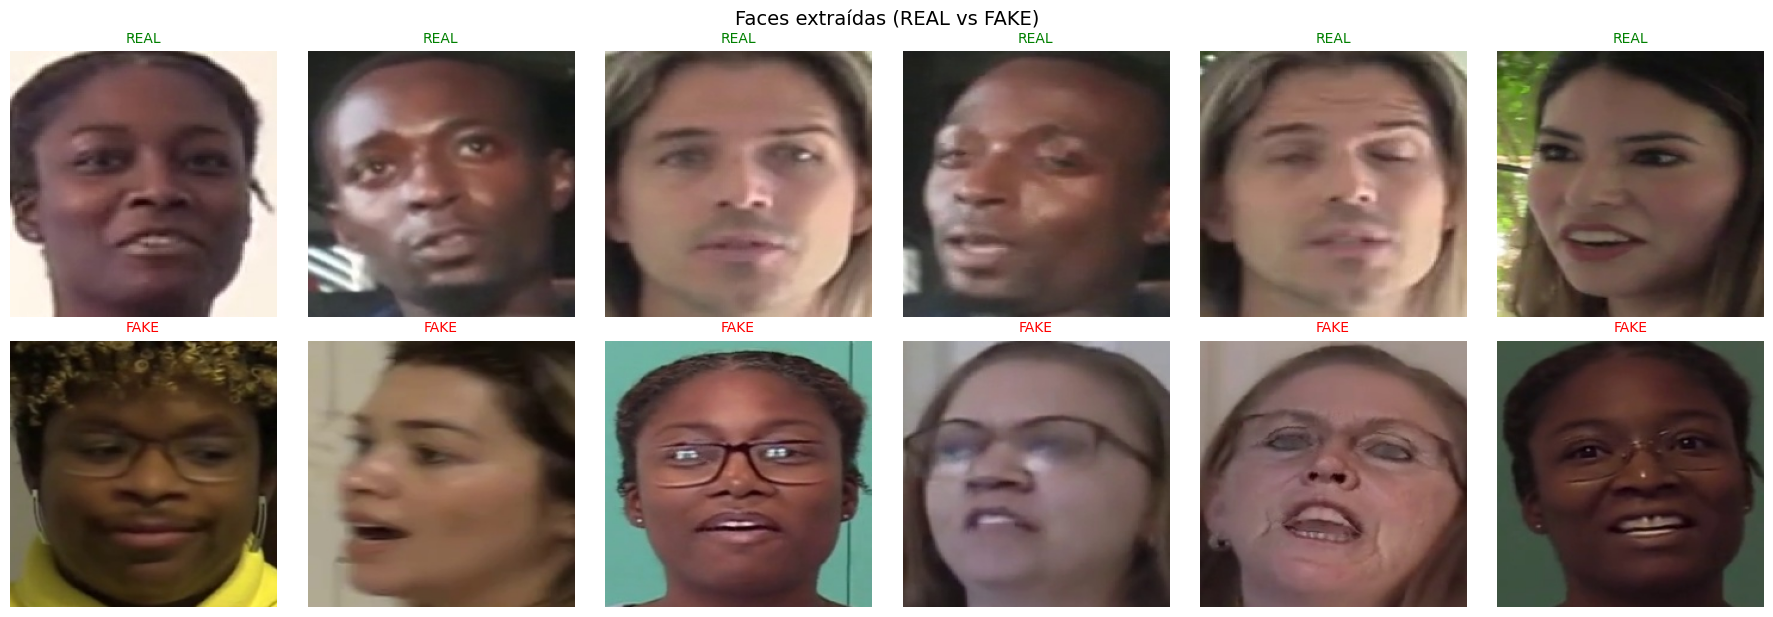

In [14]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

real_sample = faces_df[faces_df['label']=='REAL'].sample(6, random_state=SEED)
fake_sample = faces_df[faces_df['label']=='FAKE'].sample(6, random_state=SEED)

for i, (_, row) in enumerate(real_sample.iterrows()):
    img = Image.open(row['path'])
    axes[0, i].imshow(img)
    axes[0, i].set_title('REAL', color='green', fontsize=10)
    axes[0, i].axis('off')

for i, (_, row) in enumerate(fake_sample.iterrows()):
    img = Image.open(row['path'])
    axes[1, i].imshow(img)
    axes[1, i].set_title('FAKE', color='red', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.suptitle('Faces extraídas (REAL vs FAKE)', y=1.02, fontsize=14)
plt.savefig(WORK_DIR / 'faces_sample.png', dpi=120, bbox_inches='tight')
plt.show()